## 1. Signal Generation

Signal processing involves analyzing signals in both the time and frequency
domains. In this section, a synthetic signal is generated by combining two
sine waves with frequencies of 5 Hz and 20 Hz.

The 5 Hz component has an amplitude of 1, while the 20 Hz component has an
amplitude of 0.5. The signal is sampled at 200 Hz for one second.

The purpose is to create a simple signal that can later be analyzed using
the Fast Fourier Transform (FFT).

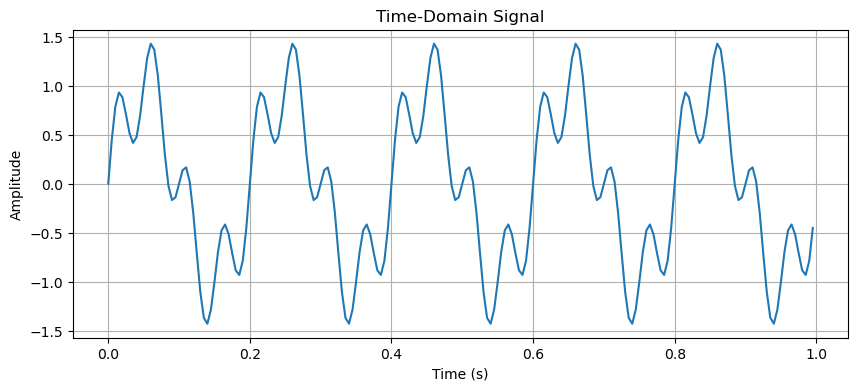

In [34]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Sampling parameters
Fs = 200
T = 1 / Fs
t = np.arange(0, 1, T)

# Signal frequencies
f1 = 5
f2 = 20

# Generate the combined signal
signal = (
    np.sin(2 * np.pi * f1 * t)
    + 0.5 * np.sin(2 * np.pi * f2 * t)
)

# Plot the signal in the time domain
plt.figure(figsize=(10, 4))
plt.plot(t, signal)

plt.title("Time-Domain Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

### Observation

The resulting waveform is a combination of two sinusoidal signals.
The individual frequencies are not immediately obvious from the
time-domain plot. The FFT will be used in the next section to identify
these frequency components.



## 2. FFT Frequency Analysis

The Fast Fourier Transform (FFT) converts a signal from the time domain
into the frequency domain.

This allows us to identify the frequencies contained in the signal.
For the signal generated above, we expect to find peaks around 5 Hz
and 20 Hz.

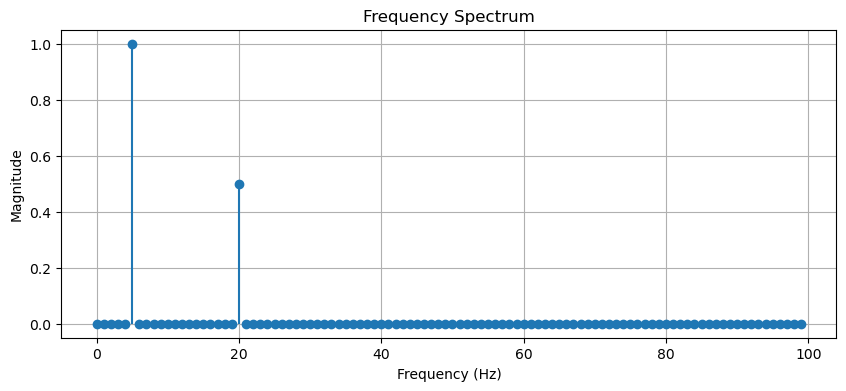

In [35]:
# Number of samples
n = len(signal)

# Calculate the FFT
fft_result = np.fft.fft(signal)

# Calculate the corresponding frequencies
fft_freq = np.fft.fftfreq(n, T)

# Keep only positive frequencies
mask = fft_freq >= 0

fft_magnitude = np.abs(fft_result[mask]) * (2 / n)
positive_freqs = fft_freq[mask]

# Plot the frequency spectrum
plt.figure(figsize=(10, 4))

plt.stem(
    positive_freqs,
    fft_magnitude,
    basefmt=" "
)

plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)

plt.show()

### Observation

The frequency spectrum shows two dominant peaks near 5 Hz and 20 Hz.
These correspond to the two sine-wave components used to generate the
original signal.

This demonstrates how FFT can reveal frequency components that may not
be obvious in the time-domain representation.

## 3. Effect of Noise on the Frequency Spectrum

Real-world measurements are often affected by noise. Noise can make it
more difficult to identify the underlying signal.

In this section, different noise amplitudes are added to the original
signal. The FFT is then used to examine how increasing noise affects
the frequency spectrum.

Three noise levels are tested: 0.2, 0.5, and 1.0.

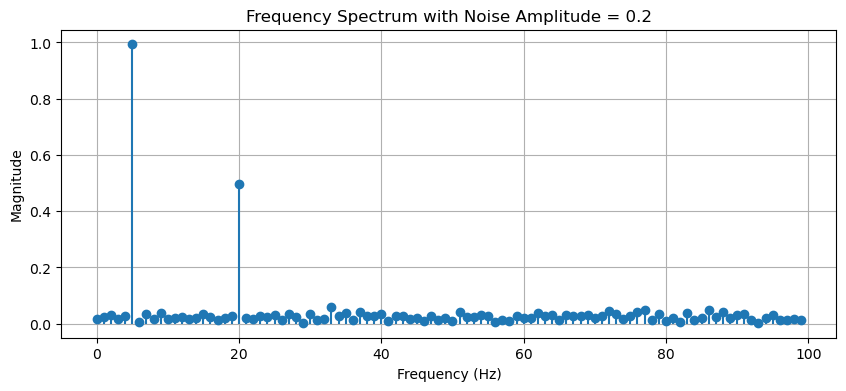

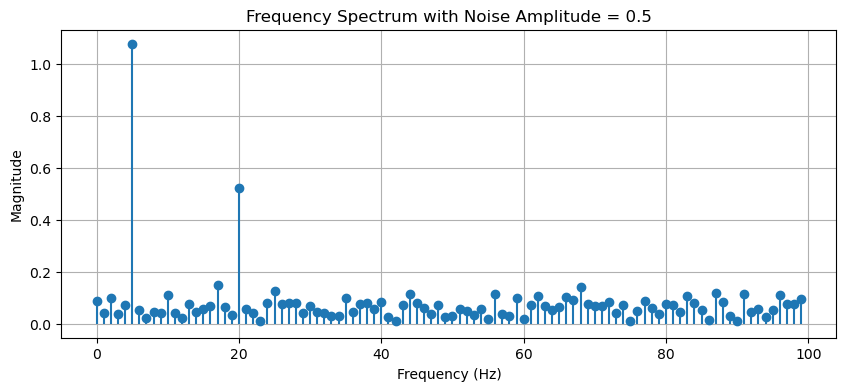

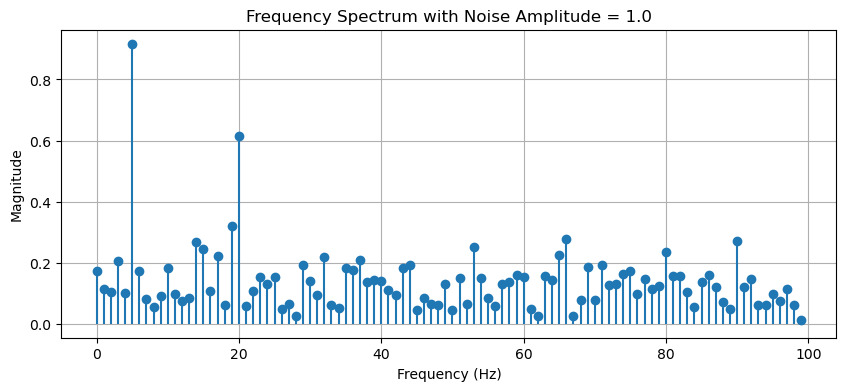

In [36]:
# Noise levels to investigate
noise_levels = [0.2, 0.5, 1.0]

for noise_amp in noise_levels:

    # Add Gaussian noise to the signal
    noisy_signal = signal + noise_amp * np.random.randn(len(t))

    # Calculate FFT
    n = len(noisy_signal)
    fft_result = np.fft.fft(noisy_signal)
    fft_freq = np.fft.fftfreq(n, T)

    # Keep positive frequencies
    mask = fft_freq >= 0

    fft_magnitude = np.abs(fft_result[mask]) * (2 / n)
    positive_freqs = fft_freq[mask]

    # Plot the noisy frequency spectrum
    plt.figure(figsize=(10, 4))

    plt.stem(
        positive_freqs,
        fft_magnitude,
        basefmt=" "
    )

    plt.title(
        f"Frequency Spectrum with Noise Amplitude = {noise_amp}"
    )
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True)

    plt.show()

### Observation

As the noise amplitude increases, the noise floor of the frequency
spectrum becomes more prominent.

At lower noise levels, the 5 Hz and 20 Hz peaks remain relatively easy
to identify. At higher noise levels, the peaks become less distinct
because the noise contributes more strongly across the spectrum.

# 4. Frequency-Domain Filtering

Noise can sometimes be reduced by removing unwanted frequency components.

Here, an ideal low-pass filter is applied in the frequency domain.
Frequency components above 30 Hz are removed.

The filtered signal is then converted back to the time domain using
the inverse FFT.

The clean, noisy, and reconstructed signals are compared to evaluate
the effect of filtering.

In [37]:
# Create a noisy signal
noise_amp = 0.8
noisy_signal = signal + noise_amp * np.random.randn(len(t))

# Calculate FFT of the noisy signal
n = len(noisy_signal)

fft_noisy = np.fft.fft(noisy_signal)
freqs = np.fft.fftfreq(n, T)

# Define the cutoff frequency
cutoff = 30

# Keep frequencies below or equal to the cutoff
filter_mask = np.abs(freqs) <= cutoff

# Apply the frequency-domain filter
fft_filtered = fft_noisy * filter_mask

# Reconstruct the filtered signal using inverse FFT
reconstructed = np.fft.ifft(fft_filtered).real

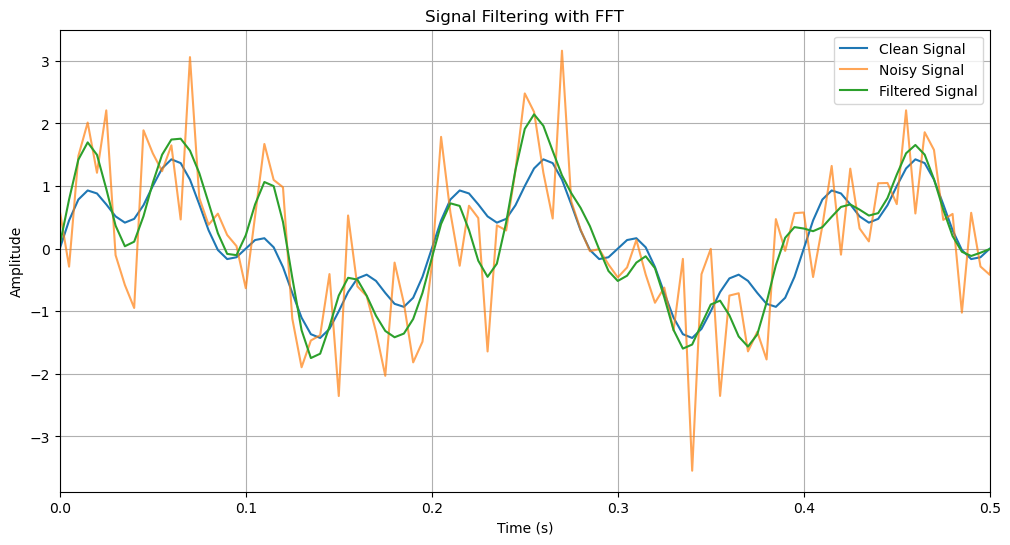

In [38]:
# Compare clean, noisy, and reconstructed signals

plt.figure(figsize=(12, 6))

plt.plot(
    t,
    signal,
    label="Clean Signal"
)

plt.plot(
    t,
    noisy_signal,
    label="Noisy Signal",
    alpha=0.7
)

plt.plot(
    t,
    reconstructed,
    label="Filtered Signal",
    linewidth=1.5
)

plt.xlim(0, 0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal Filtering with FFT")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
# Calculate mean squared error

mse_noisy = np.mean((signal - noisy_signal) ** 2)
mse_reconstructed = np.mean((signal - reconstructed) ** 2)

print(f"MSE (clean vs noisy): {mse_noisy:.4f}")
print(f"MSE (clean vs reconstructed): {mse_reconstructed:.4f}")

MSE (clean vs noisy): 0.6620
MSE (clean vs reconstructed): 0.1887


### Observation

The filtered signal is closer to the original clean signal than the
noisy signal.

The filtering process removes frequency components above the 30 Hz
cutoff. Since the main signal components are at 5 Hz and 20 Hz, they
are retained during filtering.

The mean squared error provides a simple quantitative measure of the
difference between the clean signal and the noisy or reconstructed signal.

## 5. Simulated Radio Astronomy Observation

Radio astronomy observations can contain very weak signals that are
difficult to identify directly because of noise.

To demonstrate this problem, a simplified radio astronomy observation
is simulated. A weak sinusoidal signal represents an astronomical source,
while Gaussian noise represents noise from the observation system.

The simulated astronomical signal has a frequency of 60 Hz and a small
amplitude of 0.05.

The FFT is then used to transform the noisy observation into the frequency
domain and identify the hidden signal.

In [40]:
# Sampling parameters
Fs = 1000
T = 1 / Fs

# One-second observation
t = np.arange(0, 1, T)
n = len(t)

# Simulated astronomical signal
astro_freq = 60
astro_amp = 0.05

astro_signal = (
    astro_amp *
    np.sin(2 * np.pi * astro_freq * t)
)

# Gaussian noise
noise = np.random.randn(n)

# Observed signal
observed = astro_signal + noise

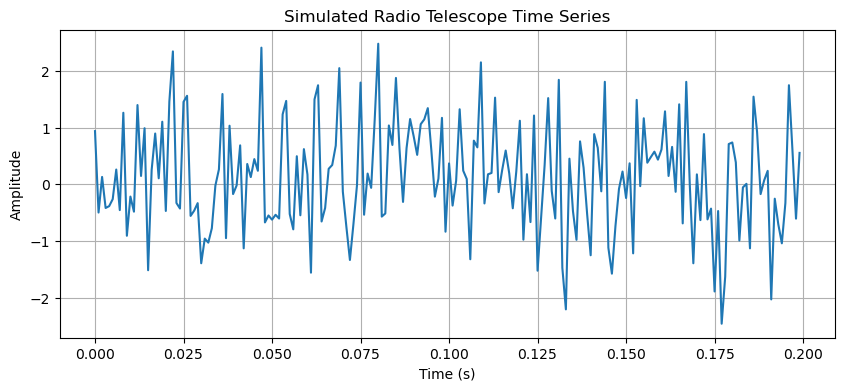

In [41]:
# Plot a portion of the simulated observation

plt.figure(figsize=(10, 4))

plt.plot(
    t[:200],
    observed[:200]
)

plt.title("Simulated Radio Telescope Time Series")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

### Observation

In the time-domain plot, the weak astronomical signal is difficult to
distinguish because it is buried within the noise.

This illustrates one of the challenges involved in detecting weak signals
in radio astronomy observations.

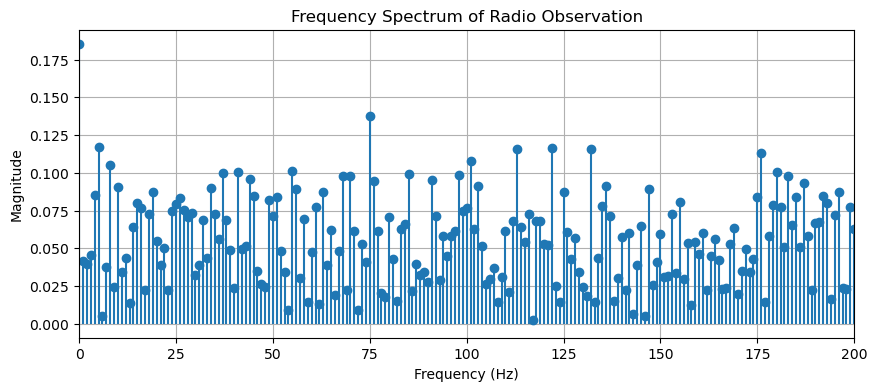

In [42]:
# Apply FFT to the radio observation

fft_result = np.fft.fft(observed)
freqs = np.fft.fftfreq(n, T)

# Keep positive frequencies
mask = freqs >= 0

fft_magnitude = np.abs(fft_result[mask]) * (2 / n)
positive_freqs = freqs[mask]

# Plot the frequency spectrum
plt.figure(figsize=(10, 4))

plt.stem(
    positive_freqs,
    fft_magnitude,
    basefmt=" "
)

plt.xlim(0, 200)

plt.title("Frequency Spectrum of Radio Observation")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)

plt.show()

### Observation

The FFT reveals a peak around 60 Hz, even though the corresponding
signal was difficult to distinguish in the time-domain observation.

This demonstrates how frequency-domain analysis can be useful for
detecting weak periodic signals hidden within noisy observations.

In real radio astronomy, similar signal-processing techniques are used
to analyze observational data and identify astronomical signals.

## Conclusion

This project demonstrated the use of the Fast Fourier Transform (FFT)
for signal analysis.

The project covered:

- Generation of synthetic signals
- Frequency-domain analysis using FFT
- The effect of noise on signal detection
- Frequency-domain filtering
- Signal reconstruction using inverse FFT
- Detection of a weak simulated astronomical signal

The radio astronomy example demonstrates how frequency-domain analysis
can help reveal signals that are difficult to identify directly in the
time domain.

### Tools and Libraries

- Python
- NumPy
- Matplotlib
- Jupyter Notebook